# Fit inspection

Visual QA of a fitted spectrum plus a parameter table with uncertainties.
All functions live in `alibz.inspection` and are exported from `alibz`:

| Function | Purpose |
|---|---|
| `plot_spectrum_overview(x, y, fit_dict, xlim=..., log_scale=...)` | raw + background, fit + peak locations, residual vs ±2σ local-noise band |
| `plot_peak_zoom(x, y, fit_dict, center_nm, span_nm=...)` | one peak: data, own component, other components, residual, parameters ± σ |
| `peak_table(x, y, fit_dict)` / `format_peak_table(rows)` | per-peak center/area/σ/γ ± 1σ, FWHM, height, S/N |
| `estimate_peak_uncertainties(x, y_bgsub, peaks)` | the underlying joint-GLS blend-group σ's |

**Reading the uncertainties:** blended peaks carry honestly inflated σ
(joint covariance per blend group); parameters at a zero bound show
`(pinned)`; for strong isolated lines σ is a statistical lower bound —
the pipeline's empirical scatter can exceed it several-fold (documented
in the docstring and pinned by `tests/test_inspection.py`).

In [1]:
import numpy as np
from alibz import (PeakyFinder, peak_table, format_peak_table,
                   plot_spectrum_overview, plot_peak_zoom)

PATH = '/Users/mwhittaker/Library/CloudStorage/GoogleDrive-mwhittaker@lbl.gov/My Drive/Postdocs/Xuan Cao/Data/LIBS/MW2-112/raw/'
SPECTRUM = 0

finder = PeakyFinder(PATH)
finder.data.load_data()
x, y = finder.data.get_data()[SPECTRUM]
fit = finder.fit_spectrum(x, y, subtract_background=True, plot=False, n_sigma=0)
print(f"{fit['sorted_parameter_array'].shape[0]} peaks fitted")

303 peaks fitted


## Full-spectrum overview
Raw + background, fitted model with peak locations, and the residual against the ±2σ local-noise band (structure outside the band = real misfit).

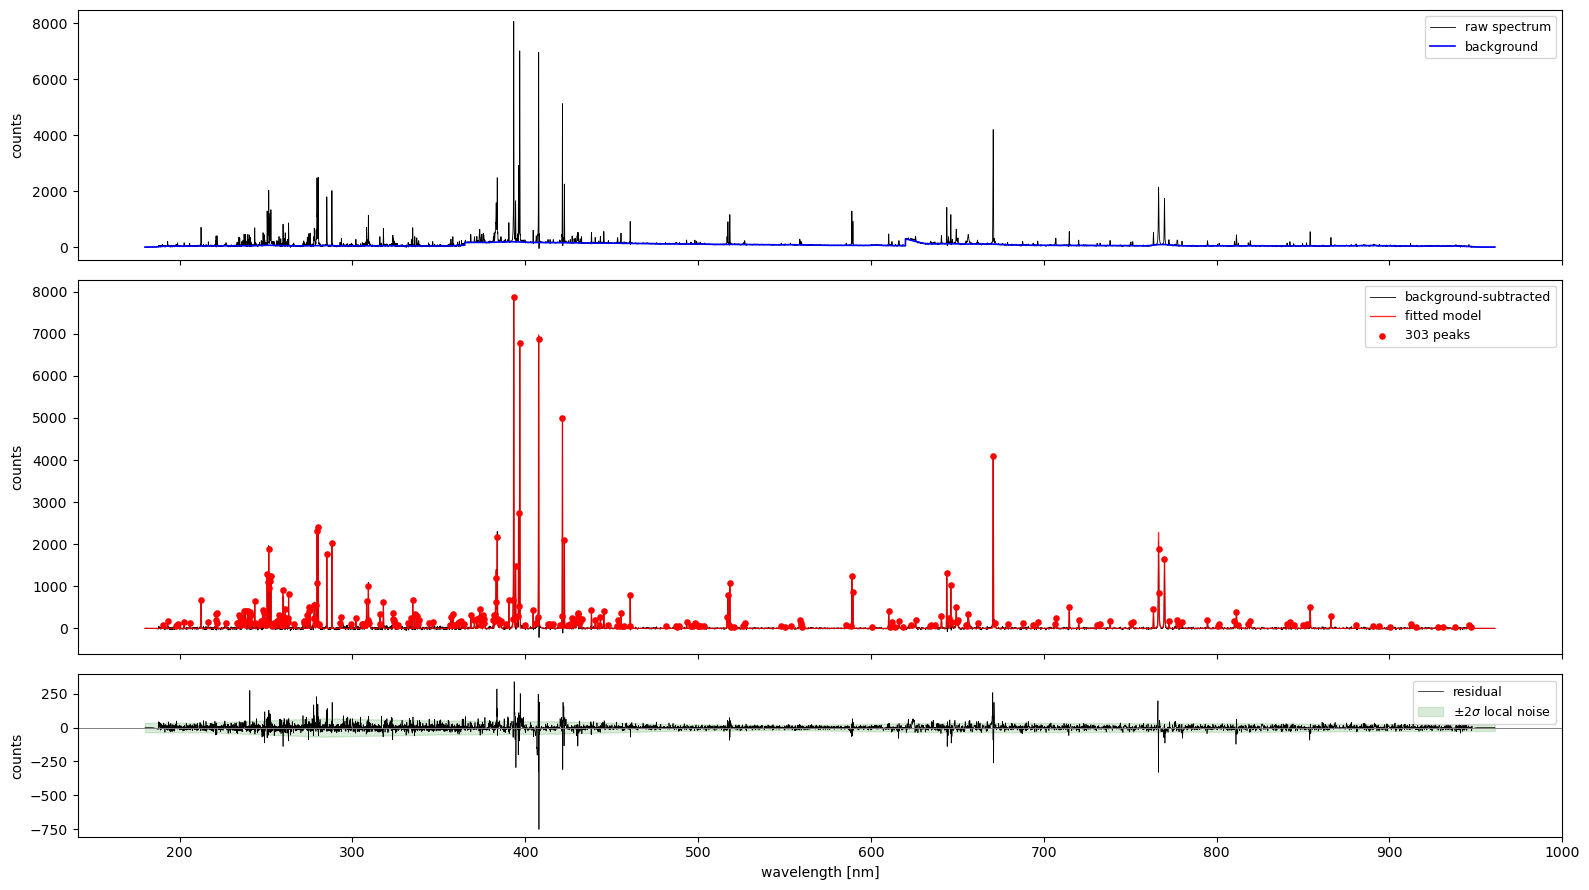

In [2]:
fig, axs = plot_spectrum_overview(x, y, fit)

## Zoom into a region
Same three panels, windowed — e.g. the Ca II H&K region.

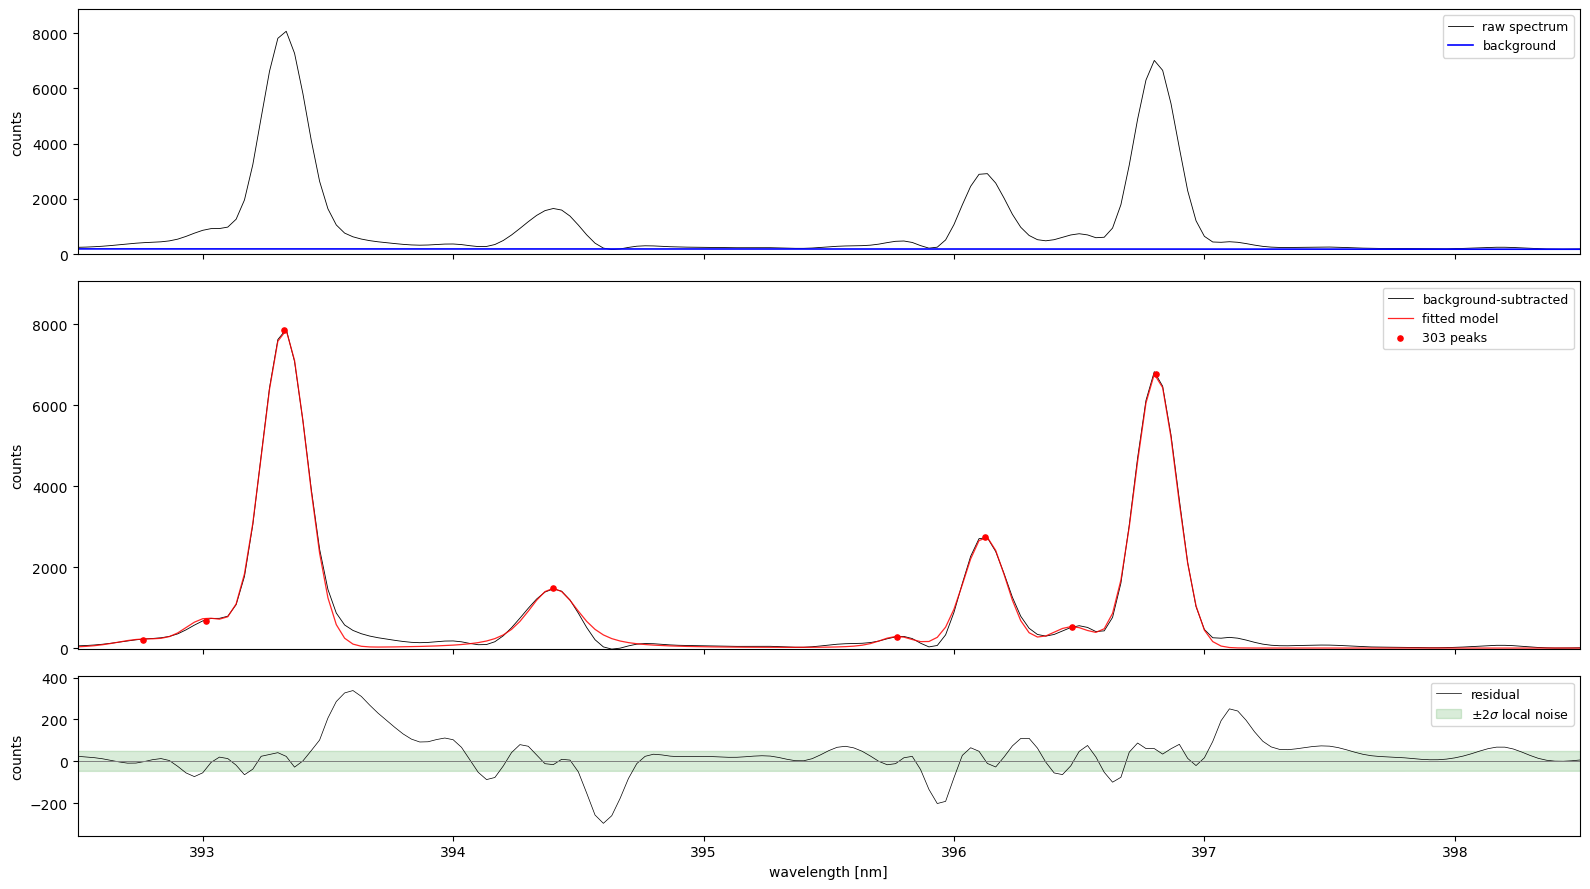

In [3]:
fig, axs = plot_spectrum_overview(x, y, fit, xlim=(392.5, 398.5))

## Single-peak inspection
Data, this peak's Voigt component, everything else, and the residual —
with fitted parameters ± uncertainties in the title.  On Li I 670.8 the
S-shaped residual outside the noise band is the self-absorption
signature (flat-topped core, suppressed wings).

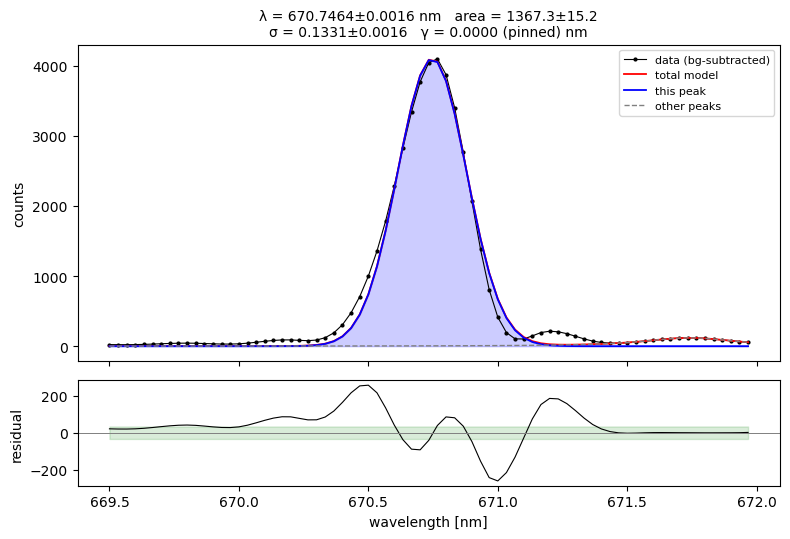

In [4]:
fig, axs = plot_peak_zoom(x, y, fit, 670.78, span_nm=2.5)

## Parameter table with uncertainties
Strongest peaks first (`sort_by="center"` for wavelength order).  Note
the K I 766.5 split components carrying honestly blend-inflated errors,
and `(pinned)` marking bound-constrained parameters.

In [5]:
rows = peak_table(x, y, fit)
print(format_peak_table(rows, max_rows=25))

             center [nm]                   area             sigma [nm]             gamma [nm]    FWHM    height     S/N
  393.3254 +/-    0.0010    1786.2 +/-     19.9     0.0905 +/-  0.0011        0.0000 (pinned)   0.213    7871.2   330.3
  407.7485 +/-    0.0009    1441.2 +/-     19.7     0.0835 +/-  0.0011        0.0000 (pinned)   0.197    6884.1   296.1
  396.8063 +/-    0.0009    1409.3 +/-     12.9     0.0828 +/-  0.0009        0.0000 (pinned)   0.195    6786.3   286.5
  670.7464 +/-    0.0016    1367.3 +/-     15.2     0.1331 +/-  0.0016        0.0000 (pinned)   0.313    4099.6   242.2
  421.5220 +/-    0.0010     975.8 +/-     11.0     0.0778 +/-  0.0010        0.0000 (pinned)   0.183    5005.2   223.5
  769.8684 +/-    0.0020     764.2 +/-     13.5     0.0802 +/-  0.0078     0.1101 +/-  0.0078   0.333    1656.4   105.8
  383.7929 +/-    0.0024     634.3 +/-     37.3     0.0722 +/-  0.0120     0.0503 +/-  0.0173   0.230    2170.4    89.7
  396.1233 +/-    0.0022     577.8 +/-  

The rows are plain dicts, so filtering and export are one-liners:

```python
suspicious = [r for r in rows if r["snr"] < 15 or r["fwhm_nm"] > 0.5]
import csv
with open("peaks.csv", "w") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys()); w.writeheader(); w.writerows(rows)
```

## Second-iteration refinement: blends vs self-absorption asymmetry

The first pass fits every feature with symmetric Voigts, so it has two failure
modes on real spectra:

- a **self-absorbed line** (flat top or red/blue shading) gets split into two
  *phantom* components — e.g. K I 766.49 fitted as 766.40 + 766.61;
- a **genuine blend** narrower than one FWHM gets fitted as a single peak.

`refine_fit` re-examines every ambiguous feature (sub-FWHM component pairs and
significant residual structure) under three local models — single Voigt (S),
self-absorption-attenuated Voigt (A), two Voigts (B) — compared by
noise-rescaled BIC and **gated by physics**: a blend verdict needs two distinct
database lines matching the fitted centers with consistent separation; an
asymmetric verdict is only *applied* when the primary line has a
resonance-capable lower level (the class that self-absorbs).

In [6]:
from alibz import refine_fit
from alibz.utils.database import Database
from alibz.utils.wavelength import estimate_wavelength_shift

db = Database("db")
shift, n_anchor = estimate_wavelength_shift(fit["sorted_parameter_array"], db)
refined, decisions = refine_fit(x, y, fit, db=db, shift_nm=shift)

from collections import Counter
print(f"shift {1000*shift:+.1f} pm ({n_anchor} anchors)")
print(f"{fit['sorted_parameter_array'].shape[0]} -> "
      f"{refined['sorted_parameter_array'].shape[0]} peaks")
print("verdicts:", dict(Counter(d['verdict'] for d in decisions)))
print("actions: ", dict(Counter(d['action'] for d in decisions)))

shift -14.9 pm (15 anchors)
303 -> 288 peaks
verdicts: {'blend': 5, 'asymmetric': 15, 'asymmetric-displaced': 12, 'single': 6, 'asymmetric-nonresonant': 12, 'ambiguous': 14}
actions:  {'split': 5, 'merge': 18, 'none': 41}


In [7]:
for d in sorted(decisions, key=lambda d: d["center"]):
    if d["action"] == "none":
        continue
    extra = ""
    if "tau_a" in d:
        extra = (f"  tau={d['tau_a']:.2f} delta={1000*d['delta_nm']:+.0f} pm"
                 f"  emission={d['emission_area']:.3g} observed={d['observed_area']:.3g}")
    print(f"{d['center']:9.3f}  {d['kind']:8s} {d['verdict']:18s} {d['action']:5s}"
          f"{'  resonance' if d['resonance_primary'] else ''}{extra}")

  198.789  pair     asymmetric         merge  resonance  tau=3.41 delta=-14 pm  emission=183 observed=44.5
  248.992  pair     asymmetric         merge  resonance  tau=2.73 delta=-17 pm  emission=591 observed=154
  251.692  pair     blend              split  resonance
  254.237  pair     asymmetric         merge  resonance  tau=3.57 delta=-1 pm  emission=198 observed=28.3
  261.203  pair     asymmetric         merge  resonance  tau=3.30 delta=+18 pm  emission=465 observed=78.5
  271.935  pair     asymmetric         merge  resonance  tau=3.12 delta=+11 pm  emission=206 observed=39.1
  278.193  pair     single             merge
  280.239  pair     asymmetric         merge  resonance  tau=0.58 delta=-28 pm  emission=760 observed=563
  309.441  pair     blend              split
  374.777  pair     asymmetric         merge  resonance  tau=3.51 delta=-20 pm  emission=716 observed=107
  383.035  pair     asymmetric         merge  resonance  tau=1.66 delta=-56 pm  emission=2.03e+03 observed=92

### K I 766.5: phantom split merged

The first pass fits the flat-topped K I resonance line as two components; the
refinement recognizes the pair as ONE self-absorbed line (model A beats two
free Voigts after the parsimony penalty, and the K I resonance physics
corroborates) and merges it. Left: first-pass fit; right: refined.

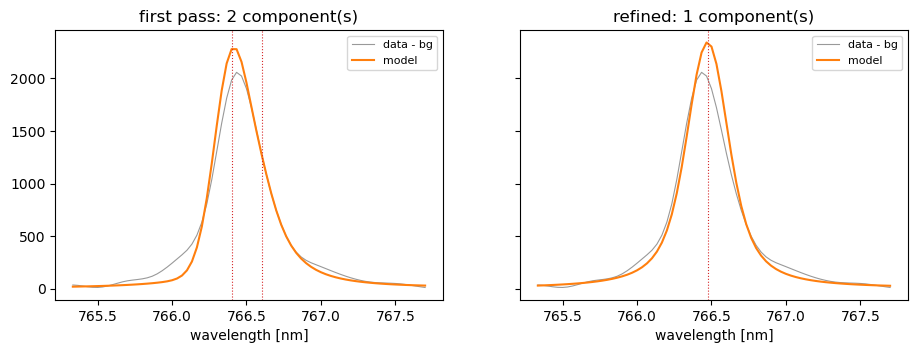

In [8]:
import matplotlib.pyplot as plt
from alibz.utils.voigt import multi_voigt

def compare_zoom(center, span=1.2):
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
    m = (x > center - span) & (x < center + span)
    bg = fit["background"]
    for ax, f, title in ((axs[0], fit, "first pass"), (axs[1], refined, "refined")):
        pk = f["sorted_parameter_array"]
        ax.plot(x[m], (y - bg)[m], color="0.6", lw=0.8, label="data - bg")
        ax.plot(x[m], multi_voigt(x[m], np.ravel(pk[:, :4])), "C1", label="model")
        near = pk[np.abs(pk[:, 1] - center) < span]
        for a, mu in near[:, :2]:
            ax.axvline(mu, color="C3", ls=":", lw=0.8)
        ax.set_title(f"{title}: {near.shape[0]} component(s)")
        ax.set_xlabel("wavelength [nm]")
        ax.legend(fontsize=8)
    return fig

compare_zoom(766.5);

### Li I 670.8: asymmetry quantified, not split

The Li I resonance doublet shows red-shaded self-absorption. The refinement
keeps ONE component but refits it with the attenuated model: the table row
carries the **observed** (attenuated) area so it stays consistent with every
other row, while the decision record reports the reconstructed unattenuated
emission area, the absorber optical depth `tau_a`, and the absorber shift
`delta`.

**Do not apply the indexer's downstream self-absorption correction on top of
rows merged this way** — the attenuation is already accounted for in the
decision record.

{'verdict': 'asymmetric', 'resonance_primary': True, 'kind': 'residual', 'action': 'merge', 'observed_area': 1487.8186207399622, 'emission_area': 2109.3549857003404, 'tau_a': 0.5886978989108242, 'delta_nm': -0.054157024193332376}


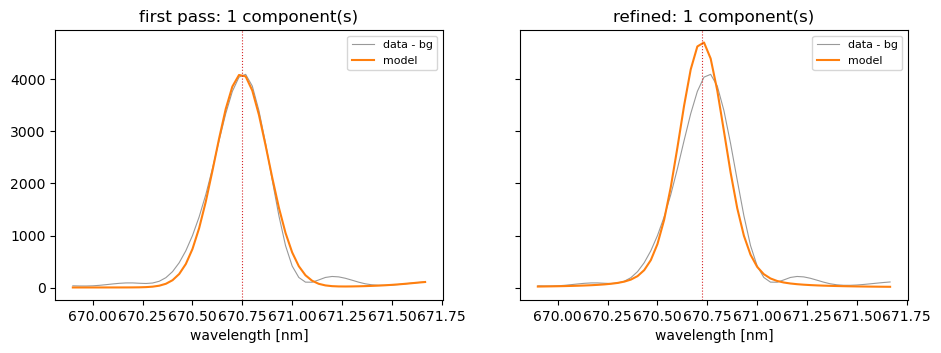

In [9]:
compare_zoom(670.78, span=0.9)
for d in decisions:
    if abs(d["center"] - 670.78) < 0.2:
        print({k: v for k, v in d.items()
               if k in ("kind", "verdict", "action", "tau_a", "delta_nm",
                        "emission_area", "observed_area", "resonance_primary")})